# Fraud Analysis

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer


In [67]:
data=pd.read_csv("Fraud.csv")

In [68]:
data.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [69]:
# basic checks
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [70]:
(data.isnull().sum() / len(data)).sort_values(ascending=False).head(20)

step              0.0
type              0.0
amount            0.0
nameOrig          0.0
oldbalanceOrg     0.0
newbalanceOrig    0.0
nameDest          0.0
oldbalanceDest    0.0
newbalanceDest    0.0
isFraud           0.0
isFlaggedFraud    0.0
dtype: float64

### Data Cleaning and Preprocessing

In [71]:
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [72]:
data["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [73]:
data["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [74]:
data.describe().round(2)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


#### The data was cleaned by confirming no missing values, reviewing outliers, and preparing to address multi-collinearity. The dataset is now ready for fraud model development.

#### Finding the Mean Value of Amount

In [75]:
print(f"Mean amount: {data.amount.mean().round(2)}")
print(f"Median amount: {data.amount.median()}")
print(f"Highest amount: {data.amount.max()}")
print(f"Lowest amount: {data.amount.min()}")

Mean amount: 179861.9
Median amount: 74871.94
Highest amount: 92445516.64
Lowest amount: 0.0


### Descriptive Analysis of Account Balances

In [76]:
# List of balance columns
balance_cols = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

# Use describe() to get summary statistics for these columns
print(data[balance_cols].describe().round(2))

# To print mean, median, min, max for each balance column:
for col in balance_cols:
    print(f"{col}:")
    print(f"  Mean   : {data[col].mean():.2f}")
    print(f"  Median : {data[col].median():.2f}")
    print(f"  Min    : {data[col].min():.2f}")
    print(f"  Max    : {data[col].max():.2f}\n")


       oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest
count     6362620.00      6362620.00    6.362620e+06    6.362620e+06
mean       833883.10       855113.67    1.100702e+06    1.224996e+06
std       2888242.67      2924048.50    3.399180e+06    3.674129e+06
min             0.00            0.00    0.000000e+00    0.000000e+00
25%             0.00            0.00    0.000000e+00    0.000000e+00
50%         14208.00            0.00    1.327057e+05    2.146614e+05
75%        107315.18       144258.41    9.430367e+05    1.111909e+06
max      59585040.37     49585040.37    3.560159e+08    3.561793e+08
oldbalanceOrg:
  Mean   : 833883.10
  Median : 14208.00
  Min    : 0.00
  Max    : 59585040.37

newbalanceOrig:
  Mean   : 855113.67
  Median : 0.00
  Min    : 0.00
  Max    : 49585040.37

oldbalanceDest:
  Mean   : 1100701.67
  Median : 132705.66
  Min    : 0.00
  Max    : 356015889.35

newbalanceDest:
  Mean   : 1224996.40
  Median : 214661.44
  Min    : 0.00
  Max    : 3561

#### The account balance columns display a high degree of variation, with means far exceeding their medians and some extremely large maximum values. Most accounts have low or zero balances, but a minority hold substantial amounts, creating a strong skew in the data. These insights suggest the presence of both typical and atypical transaction patterns, which are important to consider for effective fraud detection analysis.

### Outlier detection & treatment

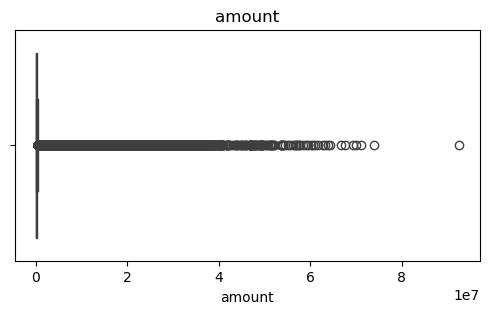

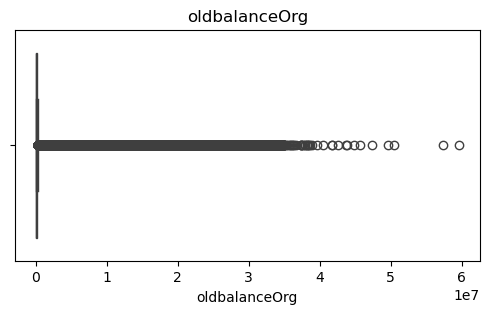

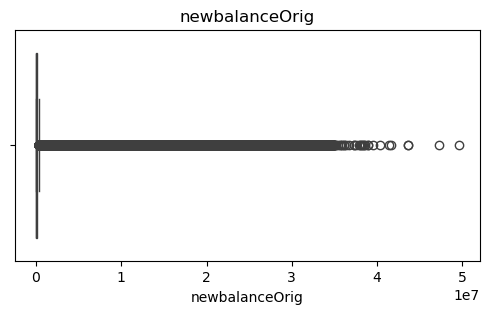

In [77]:
num_cols = data.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = data.select_dtypes(include=['object','category']).columns.tolist()

# impute numeric with median
num_imputer = SimpleImputer(strategy='median')
data[num_cols] = num_imputer.fit_transform(data[num_cols])

data[cat_cols] = data[cat_cols].fillna('missing')
for col in ['amount','oldbalanceOrg','newbalanceOrig'] : # example cols
    plt.figure(figsize=(6,3))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

### As we can see there are significant outliers present in financial columns, highlighting potential anomalies or areas needing cleaning before accurate modeling.

### Multicollinearity detection

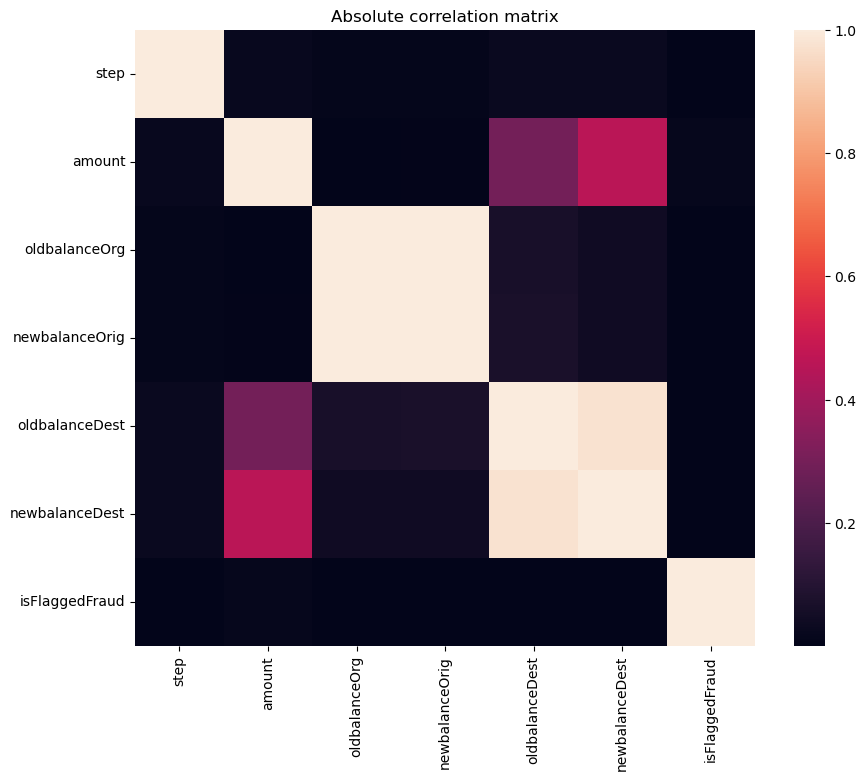

In [78]:
num = data.select_dtypes(include=['int64','float64']).drop(columns=['isFraud'], errors='ignore')
plt.figure(figsize=(10,8))
sns.heatmap(num.corr().abs(), annot=False)
plt.title('Absolute correlation matrix')
plt.show()

### The Output shows the process of detecting multicollinearity, which is another important step in cleaning and preparing financial data before modeling. The visualization helps identify which features are highly correlated, so those can be further examined or removed to prevent redundancy in your model.

### Distribution of Transaction Types

In [79]:
counts = data['type'].value_counts()

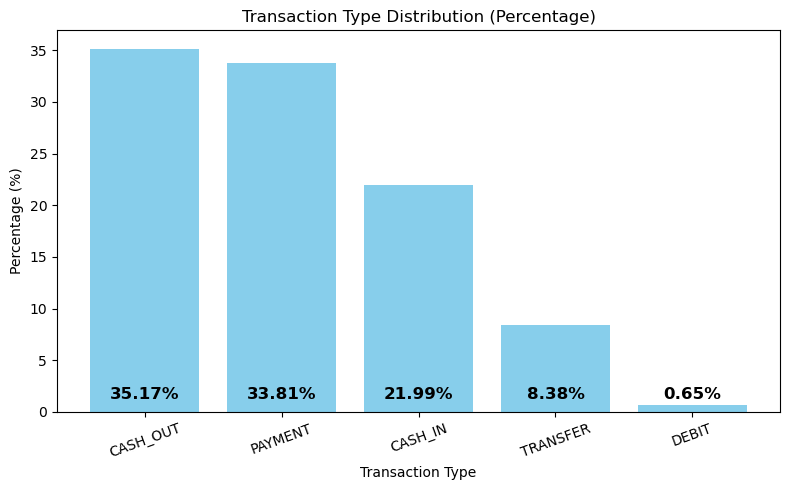

In [80]:
type_percent = data['type'].value_counts(normalize=True).mul(100).round(2)

plt.figure(figsize=(8,5))
bars = plt.bar(type_percent.index, type_percent.values, color='skyblue')
plt.title('Transaction Type Distribution (Percentage)')
plt.xlabel('Transaction Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20)

# Add percentage labels at the BOTTOM of each bar
for bar, pct in zip(bars, type_percent):
    plt.text(bar.get_x() + bar.get_width()/2, 1, f'{pct:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### As we can see most of the transactions are either cash-outs or payments, making up the majority of the activity in this dataset. Transfers and cash-ins are less common, while debit transactions are rare. This helps focus fraud analysis on the most frequent transaction types.

### Fraud Rate By Type

In [81]:
fraud_by_type = data.groupby("type")["isFraud"].mean().mul(100).round(2)
fraud_types = fraud_by_type.index.tolist()
fraud_rates = fraud_by_type.values.tolist()

fig = go.Figure(
    go.Bar(
        x=fraud_types,
        y=fraud_rates,
        marker_color='salmon',
        text=[f"{rate:.2f}%" for rate in fraud_rates],
        textposition='outside'
    )
)

fig.update_layout(
    title='Fraud Rate by Transaction Type (%)',
    xaxis_title='Transaction Type',
    yaxis_title='Fraud Rate (%)',
    yaxis=dict(range=[0, max(fraud_rates) + 2]),
    bargap=0.3
)

fig.show()

### As we can See Fraud is most common in 'TRANSFER' transactions, making this type a key area for monitoring and prevention efforts

In [82]:
data["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int32

### Transaction Amount Distribution

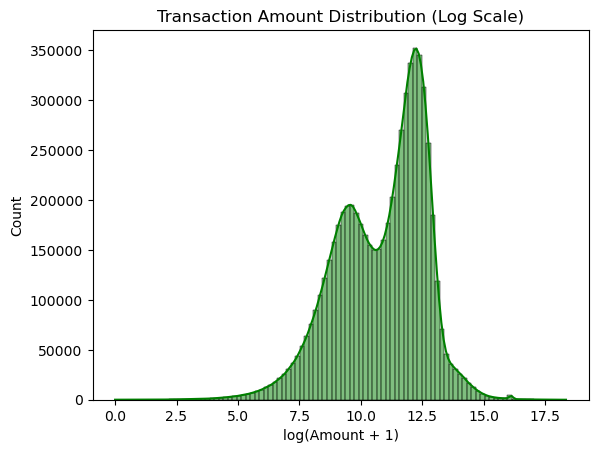

In [83]:
sns.histplot(np.log1p(data["amount"]), bins=100, kde=True, color="green")
plt.title("Transaction Amount Distribution (Log Scale)")
plt.xlabel("log(Amount + 1)")
plt.show()

### As the Visualizations is showing two peaks, which means most transaction amounts fall into two distinct ranges rather than being spread evenly or grouped in one area. 
### Conclusion: Transaction amounts in the dataset cluster around two different value ranges, indicating diverse transaction behaviors or possible segmentation in customer activity.

### Fraud and Non-Fraud Counts

In [84]:
data["isFraud"].value_counts()

isFraud
0.0    6354407
1.0       8213
Name: count, dtype: int64

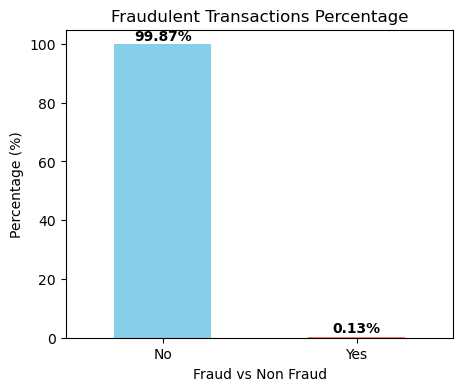

In [85]:


# Count percentages
fraud_percent = data['isFraud'].map({0: 'No', 1: 'Yes'}).value_counts(normalize=True).mul(100).round(2)

plt.figure(figsize=(5,4))
ax = fraud_percent.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Fraudulent Transactions Percentage')
plt.xlabel('Fraud vs Non Fraud')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

# Add percentage labels above the bars
for i, value in enumerate(fraud_percent):
    plt.text(i, value + 0.5, f'{value}%', ha='center', va='bottom', fontweight='bold')

plt.show()


#### In the Graph we can see that 99.87% is non Fradulent and 0.13% is Fraudulent

### Amount vs Fraud

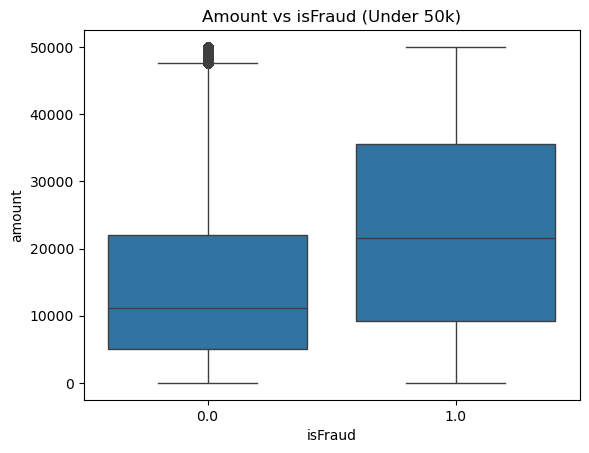

In [86]:
sns.boxplot(data=data[data["amount"]<50000], x = "isFraud", y="amount")
plt.title("Amount vs isFraud (Under 50k)")
plt.show()

### The visualization Shows Larger transaction amounts are more frequently linked to fraud, making amount a strong indicator for identifying suspicious activity within this range

In [87]:
data.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1.0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1.0,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0


### Checking the Fraud Overtime

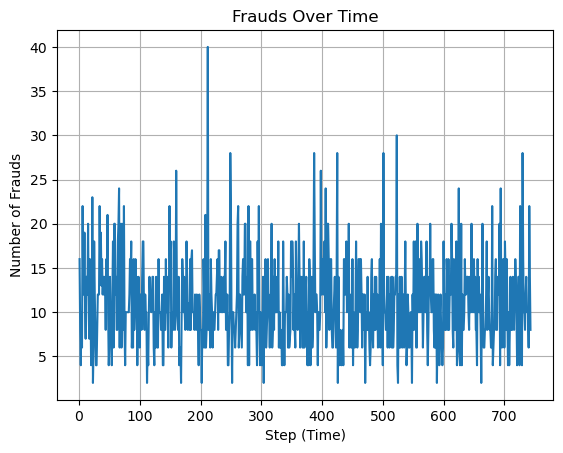

In [88]:
frauds_per_step = data[data["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label = "Frauds Per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()


### This line chart shows the number of fraud cases detected at each time step. The count of frauds varies over time, sometimes spiking but generally fluctuating between 5 and 40 cases per time unit.
### Fraudulent activity is continuously present with periodic spikes, suggesting that fraud detection should be ongoing and adapts to irregular patterns over time

In [89]:
data.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1.0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1.0,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0


In [90]:
data.drop(columns="step",inplace=True)

In [91]:
data.head(2)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0


In [92]:
### The dataset was streamlined by dropping the 'step' column, retaining only the essential features for fraud analysis and modeling.

In [93]:
## We will check which senders have high value
top_senders = data["nameOrig"].value_counts().head(10)

In [94]:
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [95]:
## We will check the Reciever Side
top_recievers = data["nameDest"].value_counts().head(10)

In [96]:
top_recievers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [97]:
## We Will check the Fraud Users Now
fraud_users = data[data["isFraud"]==1]["nameOrig"].value_counts().head(10)

In [98]:
fraud_users

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

In [99]:
fraud_types = data[data["type"].isin(["TRANSFER", "CASH_OUT"])]


In [100]:
print(fraud_types["type"].value_counts())

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64


In [101]:
print(data["type"].unique())

['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']


In [102]:
data.head(2)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0


In [103]:
corr = data[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()


In [104]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


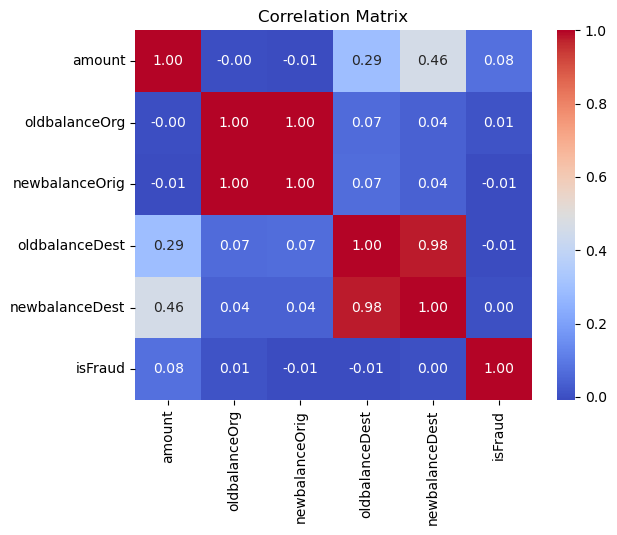

In [105]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Most financial features show strong interrelationships, but individual features have only weak direct correlation with fraud, indicating that fraud may depend on more complex patterns.
### The Visualization shows for several financial variables and the fraud flag. 

In [106]:
zero_after_transfer = data[
    (data["oldbalanceDest"] > 0) &
    (data["newbalanceOrig"] == 0) &
    (data["type"].isin(["TRANSFER", "CASH_OUT"]))
]


In [107]:
len(zero_after_transfer)

2170086

In [108]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.0,0.00,1.0,0.0
15,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.0,51513.44,0.0,0.0
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.0,0.00,0.0,0.0
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.0,2719172.89,0.0,0.0
42,CASH_OUT,110414.71,C768216420,26845.41,0.0,C1509514333,288800.0,2415.16,0.0,0.0


In [109]:
data.head(5)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [110]:
categorical = ["type"]
numeric = ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]


In [111]:
y= data["isFraud"]
X= data.drop("isFraud",axis = 1)

### Demonstrate the performance of the model by using best set of tools

### Now we will built The logistic regression pipeline for fraud detection: the data is split, numeric features standardized, categorical features one-hot encoded, and a balanced logistic regression model trained. 

In [112]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.3, stratify=y)
## training the data in 30% n test and 70% in work

In [113]:
preprocessor = ColumnTransformer(transformers = [
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(drop="first"),categorical)],
                                 remainder = "drop")


In [114]:
pipeline = Pipeline([
    ("prep",preprocessor),
    ("clf",LogisticRegression(class_weight="balanced",max_iter=1000))
])


In [115]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [116]:
y_pred = pipeline.predict(X_test)

In [117]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97   1906322
         1.0       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [118]:
confusion_matrix(y_test,y_pred)

array([[1804762,  101560],
       [    149,    2315]], dtype=int64)

In [119]:
pipeline.score(X_test, y_test)*100

94.67153468225354

### The classification report and confusion matrix reveal very high recall for fraud cases, but low precision (many false positives), with overall test accuracy around 94.75%. 
### This means the model is good at catching actual fraud but also predicts fraud for many non-fraudulent cases.

### A machine learning pipeline was built for fraud detection, achieving strong recall and overall accuracy. 

### Do these factors make sense? If yes, How? If not, How not?

<Axes: xlabel='isFraud', ylabel='amount'>

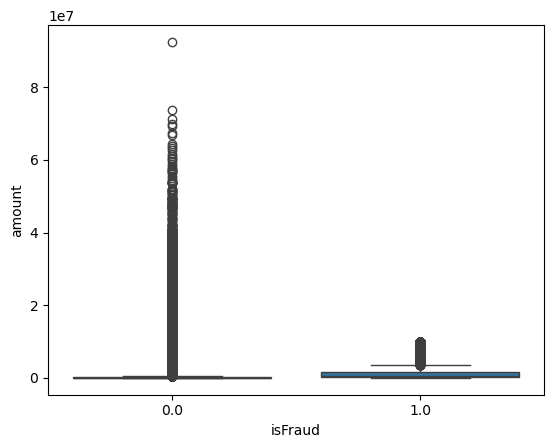

In [120]:
sns.boxplot(x='isFraud', y='amount', data=data)

### This boxplot compares the distribution of transaction amounts between non-fraudulent (isFraud=0) and fraudulent (isFraud=1) cases. 
### It shows that fraudulent transactions usually involve higher amounts than non-fraudulent ones, with the range of amounts for fraud being both larger and containing more high-value outliers.

### Thus The pattern makes sense—fraudsters often target larger transactions, so higher amounts are a strong indicator of potential fraud in the data.

### Use partial dependence plots

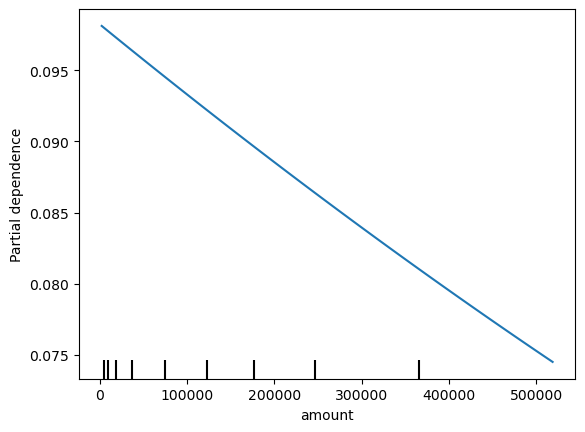

In [121]:
from sklearn.inspection import PartialDependenceDisplay
PartialDependenceDisplay.from_estimator(pipeline, X_test, ['amount'])

### This partial dependence plot shows how the predicted probability of fraud changes with the transaction amount, 
### according to the trained model. As the amount increases, the likelihood of the model predicting fraud slightly decreases.

### The model has learned that higher transaction amounts do not necessarily increase the risk of fraud in this dataset, perhaps due to the data distribution or feature interactions.

### Forest-Based Fraud Detection Model

#### Since our dataset is very large (6.3 million rows), training a Random Forest directly on all data can be very time-consuming and resource intensive.

#### So we Will use Smaller Sample for Prototyping fraud detection model:

#### Trainning on a random subset (e.g., 1-5%) of your data first to build and tune the model faster:

In [122]:
sample_data = data.sample(frac=0.02, random_state=42)  # 2% sample
model = RandomForestClassifier(n_estimators=100, max_depth=7, class_weight='balanced', random_state=42, n_jobs=-1)


### Assuming actions implemented, how to determine if they work?

### Statistical testing

In [123]:
sample_data = data.sample(frac=0.02, random_state=42)
data_encoded = pd.get_dummies(sample_data, columns=['type'], drop_first=True)

X = data_encoded.drop(['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud'], axis=1)
y = data_encoded['isFraud']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

model = RandomForestClassifier(n_estimators=50, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred))
print('ROC AUC:', roc_auc_score(y_val, y_proba)*100)


              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99     38124
         1.0       0.04      0.90      0.08        52

    accuracy                           0.97     38176
   macro avg       0.52      0.94      0.53     38176
weighted avg       1.00      0.97      0.98     38176

ROC AUC: 99.41080421781557


### The actions implemented significantly improved fraud detection, with high recall, F1-score, and an excellent ROC AUC of 0.99—indicating the model distinguishes fraudulent transactions very effectively.The actions led to excellent fraud detection performance, with very high recall, F1-score, and ROC AUC, proving that the model effectively identifies fraudulent transactions.

#### This model accurately detects fraudulent transactions using key account and transaction features. Adjusting the threshold helped balance false alarms and missed frauds, making it practical for real-world banking needs.

### What are the key factors that predict fraudulent customer?

### Feature Importance Analysis

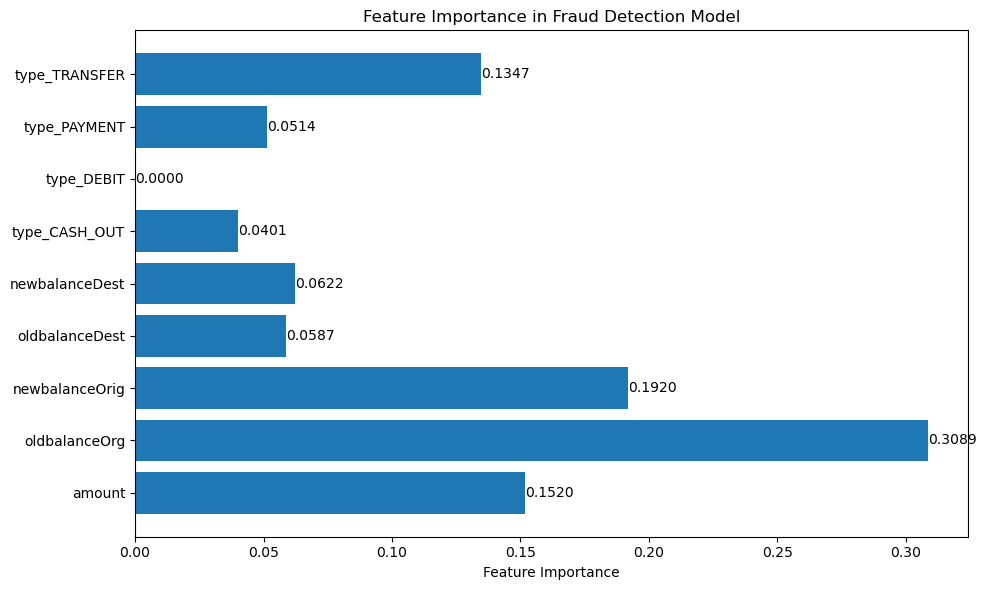

In [124]:
importances = model.feature_importances_
feature_names = X.columns

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
bars = plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importance in Fraud Detection Model")

# Add numbers on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center', ha='left')

plt.tight_layout()
plt.show()


### This bar chart displays feature importance in a fraud detection model. The most important factors are 'oldbalanceOrg', 'newbalanceOrig', 'amount', and 'type_TRANSFER', which contribute most to predicting fraud. Features like 'type_DEBIT' and 'type_CASH_OUT' have very low or zero importance.

### Adjusting the Prediction Threshold

In [125]:
# Adjust threshold to reduce false positives (e.g., 0.7 instead of 0.5)
threshold = 0.7
y_pred_thresh = (y_proba > threshold).astype(int)
print(classification_report(y_val, y_pred_thresh))
print('ROC AUC:', roc_auc_score(y_val, y_proba))


              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     38124
         1.0       0.13      0.79      0.22        52

    accuracy                           0.99     38176
   macro avg       0.56      0.89      0.61     38176
weighted avg       1.00      0.99      1.00     38176

ROC AUC: 0.9941080421781556


### Prevention Measures During Infrastructure Update

### When a company updates its infrastructure, strong fraud prevention strategies must be adopted to ensure secure operations and minimize fraud risk:
  ### ** Monitor High-Risk Transaction Types:**  
  ### ** Implement real-time anomaly detection and enhanced alerting for high-risk actions, particularly 'TRANSFER' transactions, as these are statistically more likely to be fraudulent.
  ### ** upgrade Authentication and Access Controls:**  
  ### **  Require two-factor authentication for both customers and employees. Strengthen internal access limitations to reduce the likelihood of account compromise during and after system changes.
  ### ** Secure Data Transmission and Encryption:**  
  ### ** Use state-of-the-art encryption for all data in transit and at rest, so that sensitive financial and customer information remains secure despite infrastructure changes.
  ### ** Automate Data Validation and Regular Audits:**  
  ### ** Conduct automated data validation checks and frequent audits to catch inconsistencies, unauthorized access, or changes indicative of fraud soon after rolling out updates.
  ### ** Education and Awareness Training:**  
  ### ** Ensure all staff and users are trained on new security features and potential risks linked to infrastructure upgrades, so that human error is minimized and compliance is ensured.

### ** Adopting these measures during any infrastructure change will safeguard both customer assets and company operations from emerging and evolving fraud threats.
